<h2><b>ARIMA Model: Time Series Forecasting</b></h2>
<p>This implements an ARIMA (AutoRegressive Integrated Moving Average) model to forecast solar power generation and wind onshore using historical data. The goal is to build a univariate time series model that captures patterns such as trend and seasonality in the solar energy and wind data.</p>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load data
df = pd.read_csv('../data/processed/Feature_Engineering _Dataset/feature_engineered_data.csv')
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [5]:
# Fill missing values
solar_cols = ['Solar', 'Solar_lag_1', 'Solar_lag_2', 'Solar_lag_3', 'Solar_lag_24', 'Solar_rolling_24h_mean', 'Solar_rolling_24h_std']
wind_cols = ['Wind Onshore', 'Wind Onshore_lag_1', 'Wind Onshore_lag_2', 'Wind Onshore_lag_3', 'Wind Onshore_lag_24', 'Wind Onshore_rolling_24h_mean', 'Wind Onshore_rolling_24h_std']
df[solar_cols + wind_cols] = df[solar_cols + wind_cols].fillna(0)

In [6]:
# Skip first 24 rows due to lags
df = df.iloc[24:]

In [7]:
# SOLAR MODEL
solar_series = df['Solar']
solar_train = solar_series[:-168]
solar_test = solar_series[-168:]

model_solar = ARIMA(solar_train, order=(3,1,2))
model_solar_fit = model_solar.fit()
solar_forecast = model_solar_fit.forecast(steps=168)

solar_mae = mean_absolute_error(solar_test, solar_forecast)
solar_rmse = np.sqrt(mean_squared_error(solar_test, solar_forecast))
solar_r2 = r2_score(solar_test, solar_forecast)

/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be i

In [8]:
print("Solar Forecasting:")
print(f"MAE: {solar_mae:.2f}")
print(f"RMSE: {solar_rmse:.2f}")
print(f"R²: {solar_r2:.4f}")

Solar Forecasting:
MAE: 4436.41
RMSE: 4773.25
R²: 0.0008


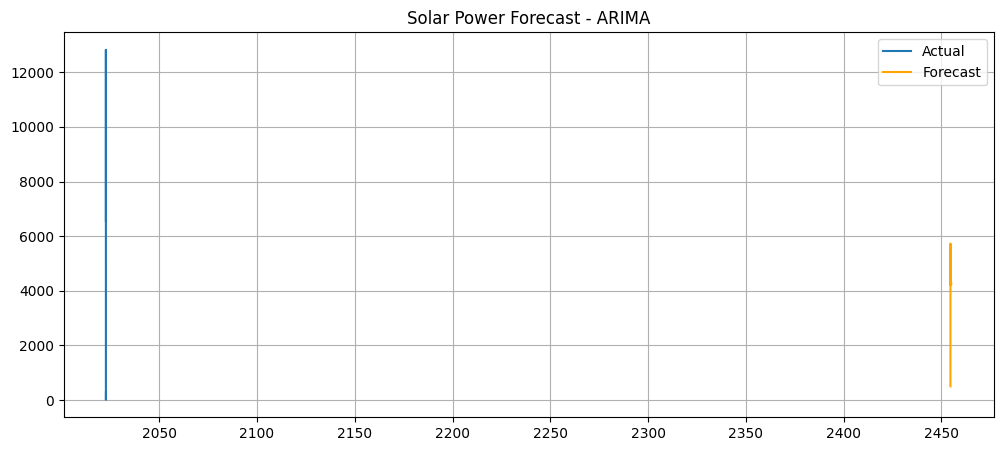

In [9]:
# Plot Solar Forecast
plt.figure(figsize=(12,5))
plt.plot(solar_series[-300:], label='Actual')
plt.plot(solar_forecast.index, solar_forecast, label='Forecast', color='orange')
plt.title("Solar Power Forecast - ARIMA")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# WIND ONSHORE MODEL
wind_series = df['Wind Onshore']
wind_train = wind_series[:-168]
wind_test = wind_series[-168:]

model_wind = ARIMA(wind_train, order=(3,1,2))
model_wind_fit = model_wind.fit()
wind_forecast = model_wind_fit.forecast(steps=168)

wind_mae = mean_absolute_error(wind_test, wind_forecast)
wind_rmse = np.sqrt(mean_squared_error(wind_test, wind_forecast))
wind_r2 = r2_score(wind_test, wind_forecast)

/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspace/.pyenv_mirror/user/current/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be i

In [11]:
print("\n Wind Onshore Forecasting:")
print(f"MAE: {wind_mae:.2f}")
print(f"RMSE: {wind_rmse:.2f}")
print(f"R²: {wind_r2:.4f}")


 Wind Onshore Forecasting:
MAE: 1943.00
RMSE: 2357.38
R²: -0.0003


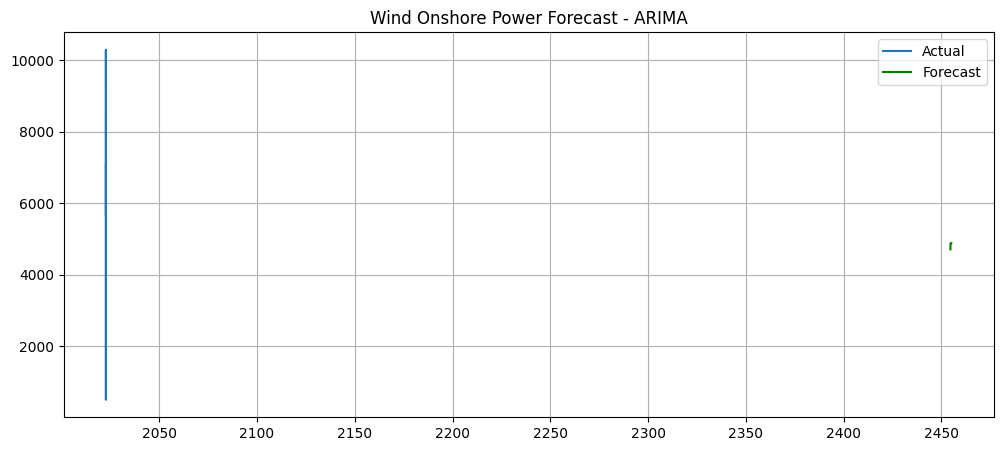

In [12]:
# Plot Wind Forecast
plt.figure(figsize=(12,5))
plt.plot(wind_series[-300:], label='Actual')
plt.plot(wind_forecast.index, wind_forecast, label='Forecast', color='green')
plt.title("Wind Onshore Power Forecast - ARIMA")
plt.legend()
plt.grid(True)
plt.show()